# Which UK city has the biggest Spotify footprint for its size?

*Current global Spotify reach across selected bands in the ten largest UK Functional Urban Areas*

## tl;dr

This notebook compares ten selected bands from each of the ten largest UK
Functional Urban Areas (FUAs). An FUA is a city plus its economically connected
commuting zone. Using the same number of bands for every area keeps the list
length fixed; it does not make the selections representative.

I look at the data three ways, each answering a different question:

1. The raw total asks which selected catalogue has the largest global Spotify
   audience.
2. The population-normalized index asks which selected catalogue is largest
   relative to its FUA population.
3. The dominant-band sensitivity removes each area's largest selected act and
   asks whether the order survives.

London, Manchester and Sheffield lead the raw totals. After population
normalization, Sheffield, Liverpool and Manchester lead. The Beatles provide
53% of Liverpool's selected total, Arctic Monkeys provide 56% of Sheffield's,
and Oasis provides 29% of Manchester's. Removing each area's largest selected
band leaves Sheffield first, moves Manchester to second and Liverpool to
third.

The main result is the all-ten population-normalized index. The removal test is
a separate stress test, not a second definition of the "best" music city.

> **Read this result narrowly:** Spotify monthly listeners are global 28-day
> audience counts captured on 18 July 2026. They are not local listeners,
> unique people across artists, historical importance or a census of each
> area's music.

## 01. What is being compared?

The geographic unit is an **OECD/EU Functional Urban Area (FUA)**. In plain
English, think of the city and its commuting orbit rather than the municipal
boundary alone. That gives the study one comparable population definition
across all four UK nations.

The study covers the ten largest UK FUAs in the OECD's 2024 population data.
I use ten reviewed bands per FUA, producing a balanced catalogue of 100
band-area assignments. A band is assigned to the FUA containing its reviewed
formation place. Solo artists are outside this study.

Giving every FUA ten bands prevents London from getting a larger total merely
because it was given a longer list. It does not solve selection bias. The
catalogues still reflect a personal shortlist,
automated discovery and editorial decisions.

| View | Calculation | What it tells us |
|---|---|---|
| Raw total | Add the ten selected bands | The absolute scale of each selected catalogue |
| Primary index | Divide that total by FUA population | Selected global Spotify attention relative to area size |
| Dominant-band sensitivity | Remove the largest selected band, then divide the other nine by population | How vulnerable the index is to one exceptional act |

The population-normalized index is the headline result. The raw total supplies
context, while the removal test is only a stress test. It does not measure the
full depth of a music scene.

## 02. Data and definitions

The analysis uses a frozen Spotify capture window beginning at **`20260718T204000Z`**
on **18 July 2026**. Two replacement rows were captured 5 minutes 22 seconds
later in the same collection run. Re-running the notebook reads local files only, so the numbers
cannot change because Spotify changed overnight.

### Population and geography

`reference/uk_fua_top20_2024.csv` contains the frozen 2024 population universe
and official FUA codes.

- [OECD definition of cities and Functional Urban Areas](https://www.oecd.org/en/data/datasets/oecd-definition-of-cities-and-functional-urban-areas.html)
- [OECD Data Explorer: Population by age and sex - Cities and FUAs](https://data-explorer.oecd.org/vis?df%5Bag%5D=OECD.CFE.EDS&df%5Bds%5D=dsDisseminateFinalDMZ&df%5Bid%5D=DSD_FUA_DEMO%40DF_AGE_SEX&lc=en)

The OECD starts with dense urban centres and adds surrounding municipalities
connected by commuting. An FUA is useful here because the same boundary logic
is applied to London, Glasgow, Cardiff and Belfast, even though this notebook
only uses the ten largest UK entries.

### Bands and Spotify reach

`data/processed/fua_top10_band_metrics_20260718T204000Z.csv` contains the 100
reviewed band-FUA assignments, Spotify artist identities, monthly listeners and
population fields. Every FUA contributes exactly ten rows.

[Spotify defines monthly listeners](https://support.spotify.com/na-en/artists/article/audience-segments/)
as the people who listened during the previous 28 days, including active and
programmed listening. The counts are global. Adding artists can count the same
person more than once, so the totals in this notebook are artist-level attention,
not unique human audiences.

Formation-place evidence has also been reviewed. The final catalogue contains
99 high-confidence assignments and one medium-confidence assignment:
Chumbawamba is retained provisionally in Leeds because sources disagree between
Leeds and Burnley. Excluding the band does not change Leeds's published ranks.

The [inclusion decision tree and data dictionary](../../reference/final_study_methodology.md)
and the [origin-confidence audit](../../reference/final_origin_confidence_audit_20260822.md)
record the row rules and evidence decisions.

### Saved result

`data/processed/fua_top10_rankings_20260718T204000Z.csv` stores the published
rankings. The notebook recomputes them from the band-level file and compares
the result with that saved table before presenting any findings. This catches
accidental changes to the calculation path.

## 03. How the index is calculated

For FUA \(c\), let \(L_{ic}\) be band \(i\)'s monthly listeners and \(P_c\)
be the FUA's 2024 population:

- **Raw total:** \(\sum_{i=1}^{10} L_{ic}\)
- **Primary index:** \(\sum_{i=1}^{10} L_{ic} / P_c\)
- **Dominant-band sensitivity:** \((\sum L_{ic} - \max L_{ic}) / P_c\)

A small worked example helps. Suppose ten selected bands sum to 50 million
monthly listeners and the FUA population is one million. The primary index is
50. If the largest band contributes 20 million, the removal-test index is 30.
Those values are ratios used for comparison. They do not mean that each
resident listened to 50 or 30 bands, because the Spotify numerator is global
and can count one person under several artists.

### Assumptions that matter

- The result describes the ten largest UK FUAs, not every UK city.
- The fixed ten-band catalogues are curated selections, not random samples or a
  census.
- Formation place is the origin rule. Birthplace, early-career scene and later
  base are different concepts.
- Monthly listeners measure current platform attention, not record sales,
  historical influence or local listening.
- Population adjusts for area size. It is not an estimate of the local audience.
- Removing the largest band tests dominant-band sensitivity but cannot repair
  catalogue-selection bias.

The next three code cells set up the local project, load and validate the frozen
inputs, and independently reproduce the saved rankings.

In [1]:
# Standard-library imports locate the repository and expose its local source code.
from pathlib import Path
import sys

# pandas handles the frozen CSV tables; assert_frame_equal performs exact
# reconciliation checks between independently computed and saved results.
import pandas as pd
from pandas.testing import assert_frame_equal
from IPython.display import display


def find_project_root() -> Path:
    """Walk upward until the repository's frozen FUA reference file is found."""
    # This makes the notebook runnable from the repository root, the notebook
    # directory or another subdirectory without hard-coding one computer's path.
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "reference" / "uk_fua_top20_2024.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from inside the uk-music-cities repository"
    )


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

# The project is not required to be installed as a package. Adding src to the
# import path lets this notebook reuse the same tested functions as the CLI and
# unit tests instead of copying calculation or plotting logic into cells.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def display_path(path: Path) -> Path:
    """Show repository-relative output paths when possible."""
    # Relative paths are easier to read and remain valid if the repository is
    # moved. The fallback preserves paths created outside the project.
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


# Imports come after the src-path setup because these modules belong to this
# repository rather than the Python standard library or installed packages.
from python_uk_bands.config import (
    FINAL_STUDY_BAND_METRICS_PATH,
    FINAL_STUDY_RANKINGS_PATH,
    FINAL_STUDY_SNAPSHOT_ID,
)
from python_uk_bands.fua import validate_top_fua_universe
from python_uk_bands.scene_depth import (
    build_primary_scene_depth_rankings,
    validate_scene_depth_dataset,
    validate_spotify_capture_window,
)
from python_uk_bands.scene_depth_visuals import (
    plot_raw_city_totals,
    plot_raw_normalized_scene_depth_rank_comparison,
    plot_ten_band_city_stack,
    plot_ten_band_population_normalized_total,
)
from python_uk_bands.visuals import apply_chart_style

# Apply the shared typography, colours and number formatting once so every
# exported chart uses the project's established visual system.
apply_chart_style()

In [2]:
# Freeze the study parameters and file paths in one place. Changing a snapshot
# or catalogue size should be an explicit edit rather than hidden notebook state.
SNAPSHOT_ID = FINAL_STUDY_SNAPSHOT_ID
EXPECTED_FUAS = 10
BANDS_PER_FUA = 10
METRICS_PATH = FINAL_STUDY_BAND_METRICS_PATH
SAVED_RANKINGS_PATH = FINAL_STUDY_RANKINGS_PATH
FUA_UNIVERSE_PATH = PROJECT_ROOT / "reference/uk_fua_top20_2024.csv"
CHART_OUTPUT_DIR = PROJECT_ROOT / "artifacts/charts"

# keep_default_na=False preserves blank evidence fields as empty strings rather
# than silently converting values such as "NA" into missing data.
band_data = pd.read_csv(METRICS_PATH, keep_default_na=False)
saved_rankings = pd.read_csv(SAVED_RANKINGS_PATH)
fua_universe = pd.read_csv(
    FUA_UNIVERSE_PATH,
    keep_default_na=False,
).head(EXPECTED_FUAS)

# Run the reusable schema and design validators first. They check required
# columns, duplicates, balanced catalogue sizes and valid metric values.
validate_scene_depth_dataset(
    band_data,
    expected_cities=EXPECTED_FUAS,
    bands_per_city=BANDS_PER_FUA,
)
validate_top_fua_universe(
    fua_universe,
    expected_rows=EXPECTED_FUAS,
    year=2024,
)

# These focused assertions document the invariants that matter to this
# notebook's interpretation. A failure stops execution before any chart can be
# mistaken for a valid result.
assert len(band_data) == EXPECTED_FUAS * BANDS_PER_FUA
assert band_data["band"].nunique() == len(band_data)
assert band_data["spotify_id"].nunique() == len(band_data)
assert band_data["catalogue_review_ready"].astype(bool).all()
assert band_data["monthly_listeners"].ge(0).all()
capture_timestamps = validate_spotify_capture_window(band_data)

# Reconcile the population repeated on band rows with the independent frozen
# FUA universe. This catches a wrong code, rank, year or denominator before it
# can affect a ratio.
observed_population = (
    band_data[
        [
            "uk_population_rank",
            "fua_code",
            "city",
            "population_year",
            "population",
        ]
    ]
    .drop_duplicates()
    .sort_values("uk_population_rank")
    .reset_index(drop=True)
)
expected_population = (
    fua_universe[
        [
            "uk_population_rank",
            "fua_code",
            "study_city_label",
            "population_year",
            "population",
        ]
    ]
    .rename(columns={"study_city_label": "city"})
    .reset_index(drop=True)
)
assert_frame_equal(
    observed_population,
    expected_population,
    check_dtype=False,
)

# Finish with a small reader-facing audit. The table is a compact receipt for
# the design rather than a dump of all 100 input rows.
quality_summary = pd.DataFrame(
    {
        "Check": [
            "Bands",
            "FUAs",
            "Bands per FUA",
            "Unique Spotify identities",
            "Reviewed catalogue rows",
            "Medium-confidence origin rows",
            "Low-confidence origin rows",
        ],
        "Value": [
            len(band_data),
            band_data["city"].nunique(),
            int(band_data.groupby("city").size().min()),
            band_data["spotify_id"].nunique(),
            int(band_data["catalogue_review_ready"].astype(bool).sum()),
            int(band_data["origin_confidence"].eq("medium").sum()),
            int(band_data["origin_confidence"].eq("low").sum()),
        ],
    }
)
display(quality_summary)

,Check,Value
0,Bands,100
1,FUAs,10
2,Bands per FUA,10
3,Unique Spotify identities,100
4,Reviewed catalogue rows,100
5,Medium-confidence origin rows,1
6,Low-confidence origin rows,0


In [3]:
# Build all three views from the band-level rows. The helper's legacy name
# contains "scene_depth", but the largest-band calculation is interpreted here
# as a dominant-band sensitivity test.
rankings = build_primary_scene_depth_rankings(
    band_data,
    metric="monthly_listeners",
    expected_cities=EXPECTED_FUAS,
    bands_per_city=BANDS_PER_FUA,
)

# Reconcile every published measure and rank against the frozen result file.
# Floating-point ratios use a tiny tolerance; integer totals and ranks must
# still agree exactly in practice.
primary_result_columns = [
    "city",
    "population",
    "input_bands",
    "highest_excluded_bands",
    "all_ten_value",
    "all_ten_ratio",
    "top_excluded_value",
    "top_excluded_ratio",
    "top_band_concentration",
    "metric",
    "raw_total_rank",
    "all_ten_rank",
    "top_excluded_rank",
]
assert_frame_equal(
    rankings[primary_result_columns]
    .sort_values("city")
    .reset_index(drop=True),
    saved_rankings[primary_result_columns]
    .sort_values("city")
    .reset_index(drop=True),
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

## 04. From bands to area-level results

### 04.01 How much does each band contribute?

This first chart sets population and total size aside. Every bar has the same
length, so it answers a composition question: is the selected total spread
across
several bands or dominated by one?

Within each FUA, segment 1 is the largest selected band, segment 2 is the next
largest, and so on. The legend provides the names. A large first segment means
the area-level result is sensitive to one act; it does not mean the remaining
music scene is shallow.

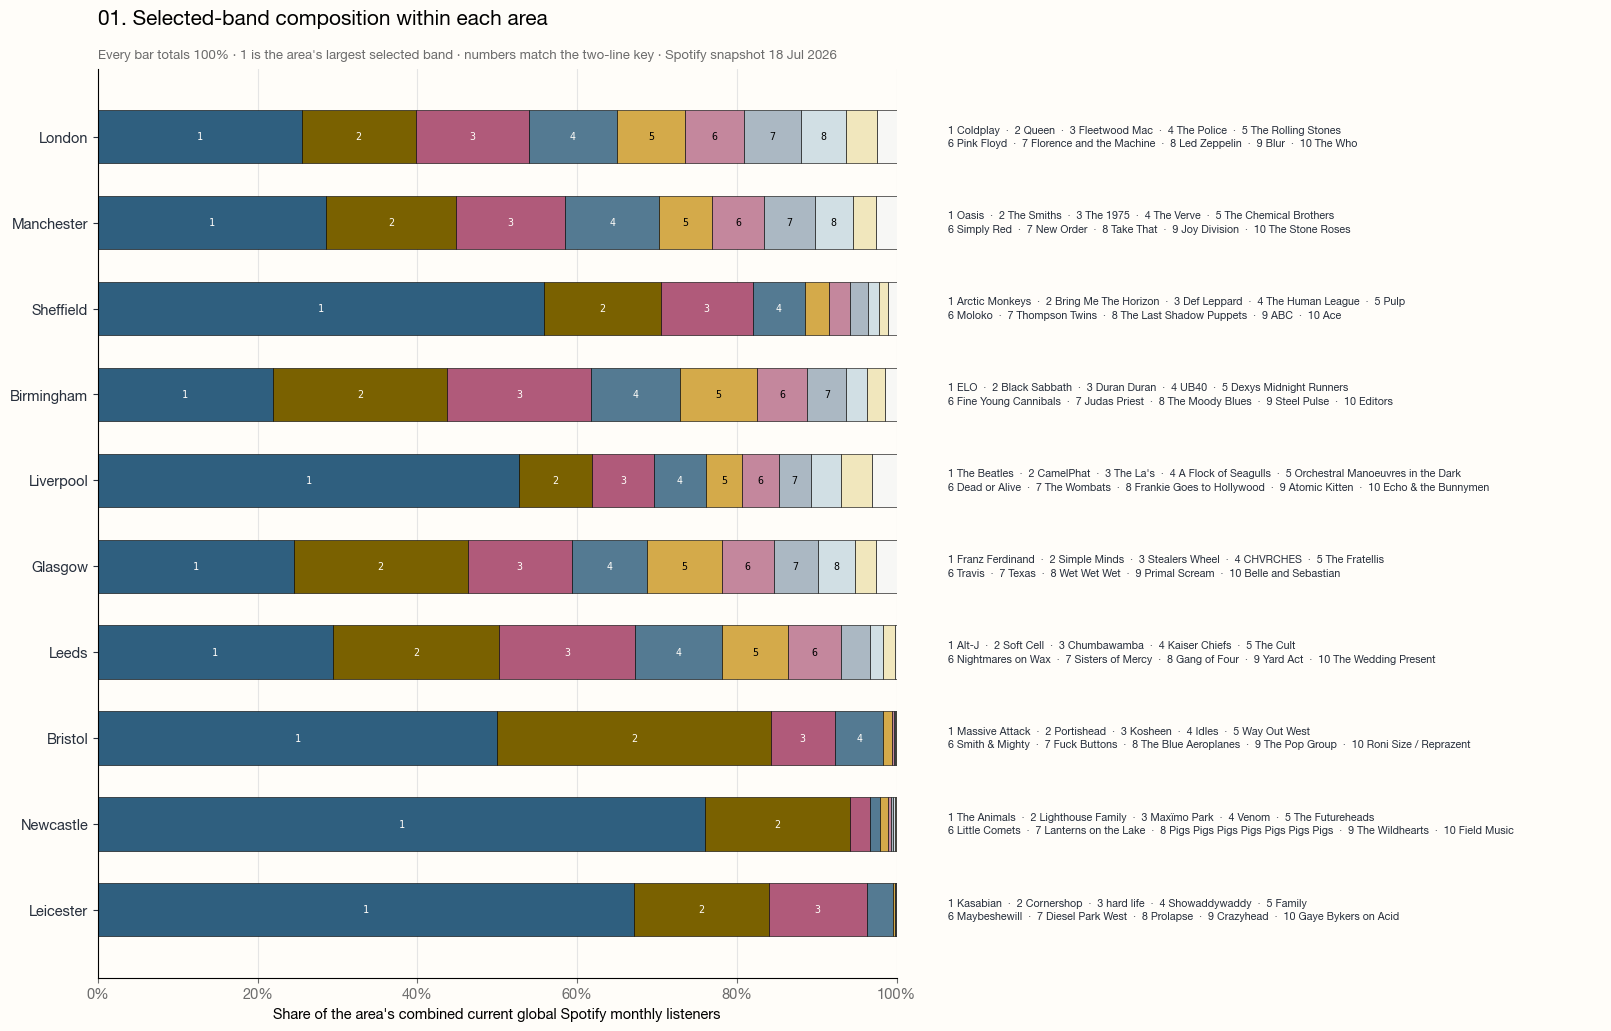

PosixPath('artifacts/charts/chart_01_fua_band_share_stack.png')

In [4]:
# Build the 100% composition chart directly from the 100 band-level rows.
# The plotting helper sorts bands within each FUA, converts listener counts to
# within-FUA shares, saves the PNG and returns its path.
figure_01_path = plot_ten_band_city_stack(
    band_data,
    snapshot_date="18 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=1,
    filename="chart_01_fua_band_share_stack.png",
)
display_path(figure_01_path)

### 04.02 Absolute reach before adjusting for population

Simply adding the ten selected bands puts London first with 316.9 million
monthly listeners, followed by Manchester with 123.0 million and Sheffield with
91.7 million. That shows the scale of each catalogue, but larger areas have a
built-in advantage. It is not yet the "punching above population weight"
comparison.

In [5]:
# Select only the columns a reader needs for the raw comparison. The stored
# calculations remain untouched; scaling below is presentation-only.
raw_fua_table = rankings[
    [
        "raw_total_rank",
        "city",
        "all_ten_value",
        "population",
        "all_ten_rank",
    ]
].copy()

# Millions are easier to scan than nine-digit listener and population counts.
raw_fua_table["all_ten_value"] = (
    raw_fua_table["all_ten_value"] / 1_000_000
).round(1)
raw_fua_table["population"] = (
    raw_fua_table["population"] / 1_000_000
).round(2)

raw_fua_table = (
    raw_fua_table
    .sort_values("raw_total_rank")
    .rename(
        columns={
            "raw_total_rank": "Raw rank",
            "city": "FUA",
            "all_ten_value": "Selected monthly listeners (millions)",
            "population": "2024 FUA population (millions)",
            "all_ten_rank": "Population-normalized rank",
        }
    )
)
display(raw_fua_table)

,Raw rank,FUA,Selected monthly listeners (millions),2024 FUA population (millions),Population-normalized rank
3,1,London,360.8,12.67,4
2,2,Manchester,138.7,3.60,3
0,3,Sheffield,93.7,1.22,1
4,4,Birmingham,83.8,3.25,5
1,5,Liverpool,71.9,1.60,2
5,6,Glasgow,44.1,1.90,6
8,7,Leeds,27.6,3.07,9
6,8,Bristol,17.4,1.03,7
7,9,Newcastle,16.2,1.22,8
9,10,Leicester,5.4,0.97,10


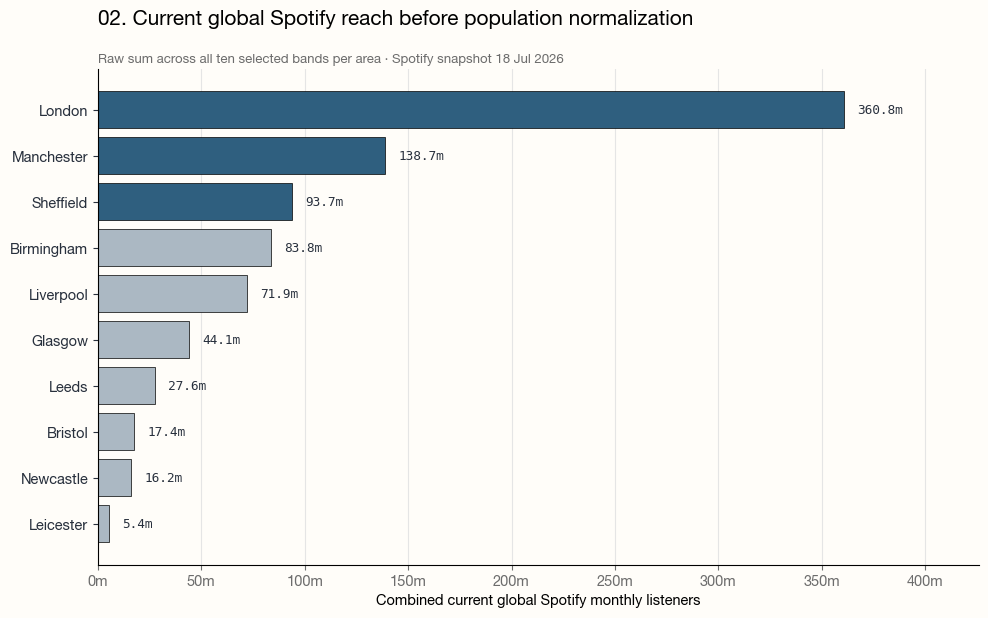

PosixPath('artifacts/charts/chart_02_raw_fua_totals.png')

In [6]:
# Plot the same raw totals. Unlike the 100% chart, bar length now represents
# absolute selected monthly listeners, so London can visibly dwarf smaller FUAs.
figure_02_path = plot_raw_city_totals(
    rankings,
    snapshot_date="18 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=2,
    filename="chart_02_raw_fua_totals.png",
)
display_path(figure_02_path)

### 04.03 Primary result: adjust for FUA population

The primary index divides each ten-band total by the matching 2024 FUA
population. Sheffield ranks first, Liverpool second and Manchester third;
London moves from first on absolute scale to fourth relative to population.

Higher values mean more selected global Spotify attention relative to the
population denominator. It does not mean the listeners live in that FUA, and it
does not count unique listeners across the ten bands.

In [7]:
# Prepare a compact primary-results table. Copying first prevents display
# formatting from modifying the validated rankings used by later cells.
all_ten_table = rankings[
    [
        "all_ten_rank",
        "city",
        "all_ten_ratio",
        "highest_excluded_bands",
        "top_band_concentration",
    ]
].copy()

# Keep two decimal places for the comparative index and convert the largest-
# band fraction (0 to 1) into a percentage that a non-expert can read directly.
all_ten_table["all_ten_ratio"] = all_ten_table["all_ten_ratio"].round(2)
all_ten_table["top_band_concentration"] = (
    100 * all_ten_table["top_band_concentration"]
).round(1)

all_ten_table = (
    all_ten_table
    .sort_values("all_ten_rank")
    .rename(
        columns={
            "all_ten_rank": "Rank",
            "city": "FUA",
            "all_ten_ratio": "Comparative index",
            "highest_excluded_bands": "Largest selected band",
            "top_band_concentration": "Largest-band share (%)",
        }
    )
)
display(all_ten_table)

,Rank,FUA,Comparative index,Largest selected band,Largest-band share (%)
0,1,Sheffield,76.92,Arctic Monkeys,55.8
1,2,Liverpool,45.00,The Beatles,52.8
2,3,Manchester,38.56,Oasis,28.6
3,4,London,28.49,Coldplay,25.5
4,5,Birmingham,25.79,ELO,21.9
5,6,Glasgow,23.27,Franz Ferdinand,24.5
6,7,Bristol,16.96,Massive Attack,50.0
7,8,Newcastle,13.27,The Animals,76.1
8,9,Leeds,8.99,Alt-J,29.4
9,10,Leicester,5.62,Kasabian,67.1


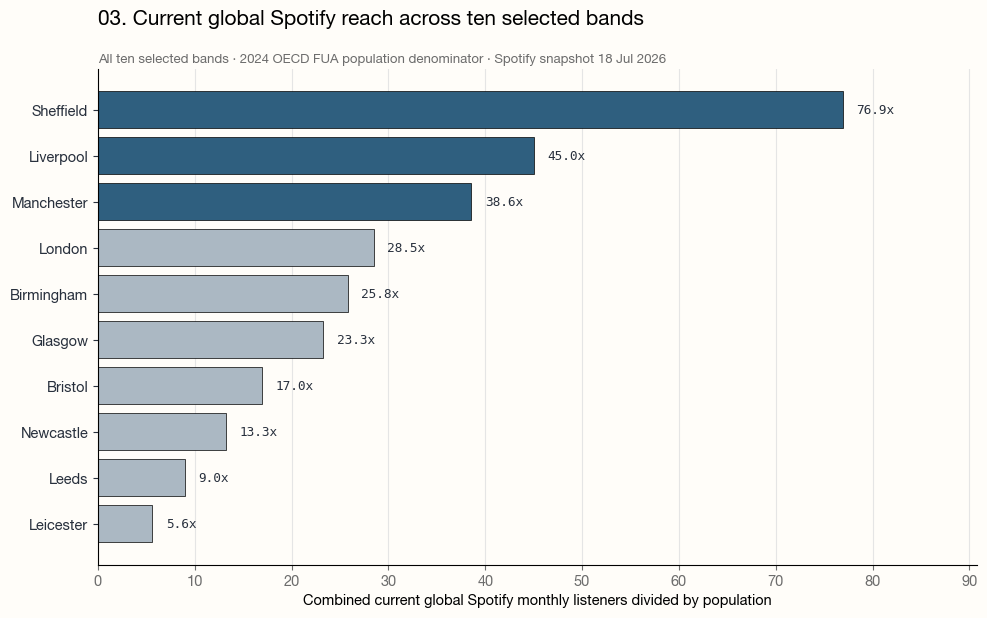

PosixPath('artifacts/charts/chart_03_fua_population_normalized_total.png')

In [8]:
# Plot the primary index on a zero-based bar scale. The subtitle records the
# population year and Spotify snapshot so the numerator and denominator cannot
# be mistaken for contemporaneous local-audience measurements.
figure_03_path = plot_ten_band_population_normalized_total(
    rankings,
    snapshot_date="18 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=3,
    filename="chart_03_fua_population_normalized_total.png",
    denominator_description="2024 OECD FUA population denominator",
)
display_path(figure_03_path)

> **Pause before interpreting the ranking**
>
> This is a comparative index of global Spotify attention divided by local
> population. It is not a local listening rate, evidence that an FUA caused a
> band's success, a historical-importance score or a complete census of the
> area's music. The numerator and denominator describe different populations
> and different dates on purpose; the result is useful for comparison, not for
> estimating resident behaviour.

## 05. Why remove the largest selected band?

The selected catalogues are not equally concentrated. The Beatles provide
52.8% of Liverpool's total, Arctic Monkeys provide 55.8% of Sheffield's and
Oasis provides 28.6% of Manchester's.

All of those bands remain in the primary result. The extra test temporarily
removes each FUA's largest selected act and recalculates the population index
with the other nine. Think of it as asking whether the ranking survives after
the biggest band leaves the room.

This tests dominant-band sensitivity within the chosen catalogue. Calling it a
measure of complete "scene depth" would claim more than ten selected bands can
show.

## 06. Dominant-band sensitivity: recalculate with nine bands

After removing each FUA's largest selected band, Sheffield remains first,
Manchester moves from third to second and Liverpool moves from second to third.
London and Birmingham remain fourth and fifth.

This is the notebook's only alternative ranking. Every FUA still contributes
the same number of bands: nine. The point is not to erase famous acts, but to
show how much they influence the selected-catalogue result.

In [9]:
# Start from the validated rankings and keep both the primary and removal-test
# ranks so movement can be read in one table.
largest_excluded_table = rankings[
    [
        "top_excluded_rank",
        "city",
        "top_excluded_ratio",
        "highest_excluded_bands",
        "all_ten_rank",
    ]
].copy()

# A positive value means the FUA moved toward rank 1 after its largest selected
# band was removed; a negative value means it fell. The ratio is rounded only
# for display.
largest_excluded_table["rank_change"] = (
    largest_excluded_table["all_ten_rank"]
    - largest_excluded_table["top_excluded_rank"]
)
largest_excluded_table["top_excluded_ratio"] = (
    largest_excluded_table["top_excluded_ratio"].round(2)
)

largest_excluded_table = (
    largest_excluded_table
    .sort_values("top_excluded_rank")
    .rename(
        columns={
            "top_excluded_rank": "Rank after removal",
            "city": "FUA",
            "top_excluded_ratio": "Other-nine comparative index",
            "highest_excluded_bands": "Band removed",
            "all_ten_rank": "Primary all-ten rank",
            "rank_change": "Places gained",
        }
    )
)
display(largest_excluded_table)

,Rank after removal,FUA,Other-nine comparative index,Band removed,Primary all-ten rank,Places gained
0,1,Sheffield,33.97,Arctic Monkeys,1,0
2,2,Manchester,27.53,Oasis,3,1
1,3,Liverpool,21.26,The Beatles,2,-1
3,4,London,21.22,Coldplay,4,0
4,5,Birmingham,20.14,ELO,5,0
5,6,Glasgow,17.57,Franz Ferdinand,6,0
6,7,Bristol,8.48,Massive Attack,7,0
8,8,Leeds,6.35,Alt-J,9,1
7,9,Newcastle,3.17,The Animals,8,-1
9,10,Leicester,1.85,Kasabian,10,0


## 07. Put the three views side by side

The final chart uses one rank scale for the raw total, the primary
population-normalized index and the dominant-band sensitivity. Follow one FUA
across the three markers to see whether its position is driven mainly by area
size, population adjustment or one very large selected act.

Rank 1 is strongest within this ten-FUA comparison. The chart compares methods;
it does not attach uncertainty intervals to the ranks.

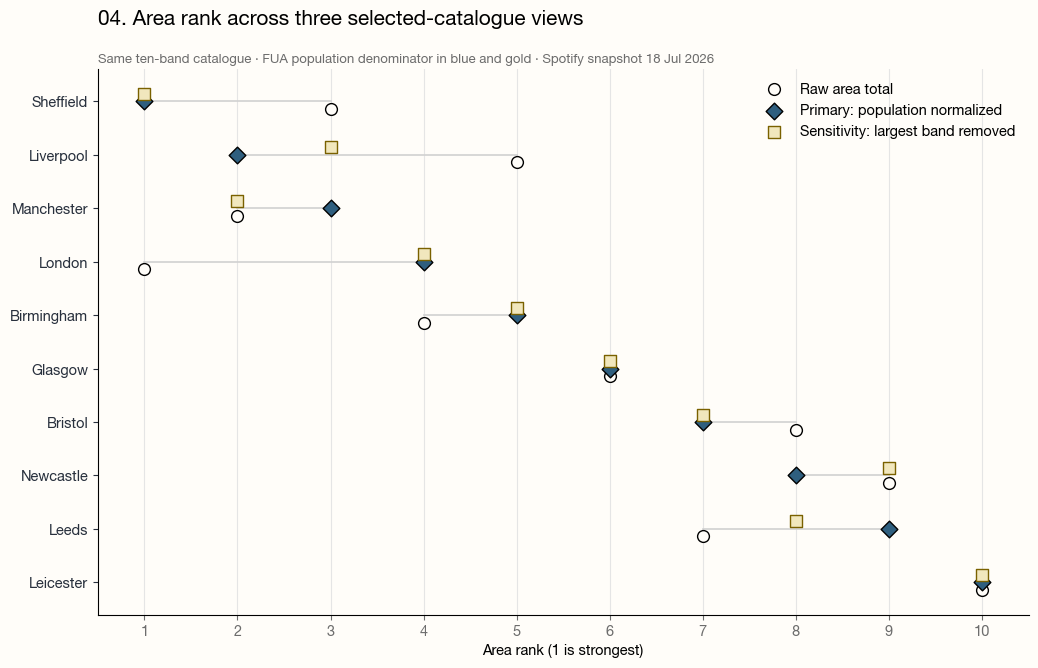

PosixPath('artifacts/charts/chart_04_raw_normalized_scene_depth_fua_ranks.png')

In [10]:
# Create the rank-comparison chart from the same validated table. The shared
# helper draws one line per FUA and one marker per analytical view, then saves
# the fourth publication-ready PNG.
figure_04_path = plot_raw_normalized_scene_depth_rank_comparison(
    rankings,
    snapshot_date="18 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=4,
    filename="chart_04_raw_normalized_scene_depth_fua_ranks.png",
)
display_path(figure_04_path)

## 08. What the results support

Within the ten largest UK FUAs and this balanced 100-band catalogue:

- London, Manchester and Sheffield have the largest absolute selected totals.
- Sheffield, Liverpool and Manchester lead after population normalization.
- Sheffield, Manchester and Liverpool lead after each largest selected band is
  removed.
- Liverpool and Sheffield rely more heavily on their largest selected act than
  Manchester does. Newcastle is the most concentrated catalogue: The Animals
  provide 76.1% of its selected total.

The headline remains the all-ten population-normalized index. The removal test
answers a narrower question about sensitivity to one band.

Sheffield performs strongly under both published views of this selected
catalogue, while several other positions depend heavily on scale or a dominant
act. That is a much narrower conclusion than "Sheffield is Britain's best music
city."

## 09. Limitations worth keeping beside the result

The hard limit is the selection itself. Ten bands per FUA keeps catalogue
length constant, but the lists still reflect genre and editorial choices. They
exclude solo artists and are not a random sample or census. A balanced catalogue can still
be an unrepresentative catalogue.

There are other constraints:

- The study covers the ten largest UK FUAs, not every UK city.
- Formation place is a practical origin rule, not a complete account of where a
  band came from or developed.
- All 100 assignments have reviewed evidence. Ninety-nine are high-confidence;
  Chumbawamba's provisional Leeds assignment is medium-confidence because
  sources disagree between Leeds and Burnley. Excluding it does not change
  any of Leeds's published ranks.
- Monthly listeners are volatile global 28-day attention observed once. They
  are not historical impact, sales or local listening.
- Summing artists does not produce a unique-person audience count.
- The sources have a documented two-year mismatch: Spotify attention is
  measured in 2026, while 2024 is the latest complete observed OECD
  population year available for UK FUAs.
- Dividing July 2026 global attention by 2024 FUA population creates a
  comparative index, not a behavioural rate.
- Removing the largest selected band cannot remove catalogue-selection bias.

In short, this notebook ranks one frozen selected catalogue against a consistent
population denominator, then shows how much each area's largest selected band
affects the order.

Charts are saved under `artifacts/charts`.

## Appendix A. Why the geography changed

Earlier versions used a mixed collection of census built-up areas inherited
from the original shortlist. That was fine for exploration, but the list was not ranked
by population and did not apply one boundary definition across
all four UK nations.

The final version starts from the official OECD population table and uses FUAs
throughout. This changes the panel: Bradford is part of the Leeds FUA rather
than a separate entry, Nottingham ranks eleventh, and Newcastle and Leicester
enter the ten largest FUAs. The earlier built-up-area notebook remains in the
project snapshots, so the change is visible rather than quietly overwritten.

Sources:

- [OECD FUA definition and boundary resources](https://www.oecd.org/en/data/datasets/oecd-definition-of-cities-and-functional-urban-areas.html)
- [OECD population dataset used for the frozen 2024 universe](https://data-explorer.oecd.org/vis?df%5Bag%5D=OECD.CFE.EDS&df%5Bds%5D=dsDisseminateFinalDMZ&df%5Bid%5D=DSD_FUA_DEMO%40DF_AGE_SEX&lc=en)

## Appendix B. Useful dead ends

Some plausible data sources did not hold up under review.

Google Trends was rejected as the common popularity measure because its sampled,
request-normalized results changed across batches. MusicBrainz remains useful
for discovering and matching bands, but a database field cannot settle every
editorial question about formation place or what counts as a band. Earlier
five-band and built-up-area analyses remain in the audit trail, but they do not
feed this estimator.

Dead ends are part of the method here. Recording them prevents an unstable or
ill-fitting source from quietly returning later with a nicer chart.